In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats 
import seaborn as sns
from scipy.stats import ttest_ind 
from scipy.stats import ttest_rel
import pandas as pd

In [3]:
df_hyp = pd.read_excel('alpha2hypnosis_results.xlsx')
df_hyp.head()

,subject,task,alpha2_relative_bandpower,procedure type,description type
0,sub-01,task-baseline1,0.103287,NaN,NaN
1,sub-01,task-baseline2,0.159116,NaN,NaN
2,sub-01,task-experience1,0.095561,embedded,hypnosis
3,sub-01,task-experience2,0.078832,confusion,control
4,sub-01,task-experience3,0.070760,relaxation,hypnosis


In [4]:
df_med=pd.read_excel('alpha2meditation_results.xlsx')
df_med.head()

,subject,task,alpha2_relative_bandpower
0,sub-001,med1breath,0.118802
1,sub-001,med2,0.073943
2,sub-001,think1,0.121088
3,sub-001,think2,0.082874
4,sub-002,med1breath,0.109534


In [5]:
#meditation
#exclude control condition from sub 25 to sub 55
subject_ids = df_med["subject"].str.extract(r"(\d+)").astype(int)[0]
df_med_filtered = df_med[(subject_ids < 25) | (subject_ids > 55)]
med_tasks = ["med1breath", "med2"]
think_tasks = ["think1", "think2"]
meditation_cond = (
    df_med_filtered[df_med_filtered["task"].isin(med_tasks)]
    .groupby("subject")["alpha2_relative_bandpower"]
    .mean()
    .rename("med")
)

thinking_cond = (
    df_med_filtered[df_med_filtered["task"].isin(think_tasks)]
    .groupby("subject")["alpha2_relative_bandpower"]
    .mean()
    .rename("think")
)

med_think = pd.concat([meditation_cond, thinking_cond], axis=1).dropna()
#paired t-test
t_meditation, p_meditation = ttest_rel(med_think["med"], med_think["think"])
print("Meditation vs Thinking: t =", t_meditation, "p =", p_meditation)

Meditation vs Thinking: t = -1.4554168755591943 p = 0.15094538619183628


In [6]:
#hypnosis
#only include conventional hypnotic and unconventional induction
baseline_tasks = ["task-baseline1", "task-baseline2"]

baseline_cond = (
    df_hyp[df_hyp["task"].isin(baseline_tasks)]
    .groupby("subject")["alpha2_relative_bandpower"]
    .mean()
    .rename("baseline")
)

procedure_cond = (
    df_hyp[df_hyp["description type"] == "hypnosis"]
    .groupby("subject")["alpha2_relative_bandpower"]
    .mean()
    .rename("tasks")
)

hypo = pd.concat([baseline_cond, procedure_cond], axis=1).dropna()

t_hypnosis, p_hypnosis = ttest_rel(hypo["tasks"], hypo["baseline"])
print("Hypnosis Procedure vs Baseline: t =", t_hypnosis, "p =", p_hypnosis)

Hypnosis Procedure vs Baseline: t = -7.113198039327261 p = 4.430902102482038e-09


In [7]:
med_diff = (meditation_cond - thinking_cond).rename("med_diff")
hyp_diff = (procedure_cond - baseline_cond).rename("hyp_diff")
med_d = med_diff.dropna().values
hyp_d = hyp_diff.dropna().values

In [8]:
print("Meditation difference scores:")
print(med_diff)
print("Hypnosis difference scores:")
print(hyp_diff)

Meditation difference scores:
subject
sub-001   -0.005608
sub-002    0.014248
sub-003    0.004425
sub-004    0.020220
sub-005    0.009430
sub-006   -0.019281
sub-007   -0.016158
sub-008    0.008433
sub-009   -0.066392
sub-010   -0.006190
sub-011   -0.004924
sub-012    0.000029
sub-013    0.000076
sub-014    0.007735
sub-015   -0.022396
sub-016   -0.021590
sub-017   -0.056500
sub-018   -0.022343
sub-019    0.007498
sub-020   -0.028924
sub-021   -0.039121
sub-022    0.025723
sub-023   -0.085283
sub-024    0.008735
sub-061         NaN
sub-062    0.019554
sub-063   -0.001549
sub-064   -0.001938
sub-065    0.004483
sub-066    0.017218
sub-067    0.007525
sub-068   -0.029595
sub-069   -0.027230
sub-070   -0.014505
sub-071    0.002182
sub-072    0.005761
sub-073   -0.002432
sub-074   -0.006154
sub-075    0.007660
sub-076   -0.024924
sub-077    0.007913
sub-078   -0.007842
sub-079    0.002883
sub-080   -0.017432
sub-081    0.012136
sub-082    0.009883
sub-083   -0.053429
sub-084   -0.000349
su

In [9]:
from scipy.stats import ttest_ind

t, p = ttest_ind(med_d, hyp_d, equal_var=False)  # Welch's t-test
print("Contrast comparison: t =", t, "p =", p)
cohens_d = (np.mean(hyp_d) - np.mean(med_d)) / np.sqrt((np.std(hyp_d, ddof=1)**2 + np.std(med_d, ddof=1)**2) / 2)
print("Cohen's d for contrast:", cohens_d)

Contrast comparison: t = 5.308602281073677 p = 9.098583560150758e-07
Cohen's d for contrast: -1.0366220765775334


C:\Users\tramy\AppData\Local\Temp\ipykernel_26156\1736803288.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


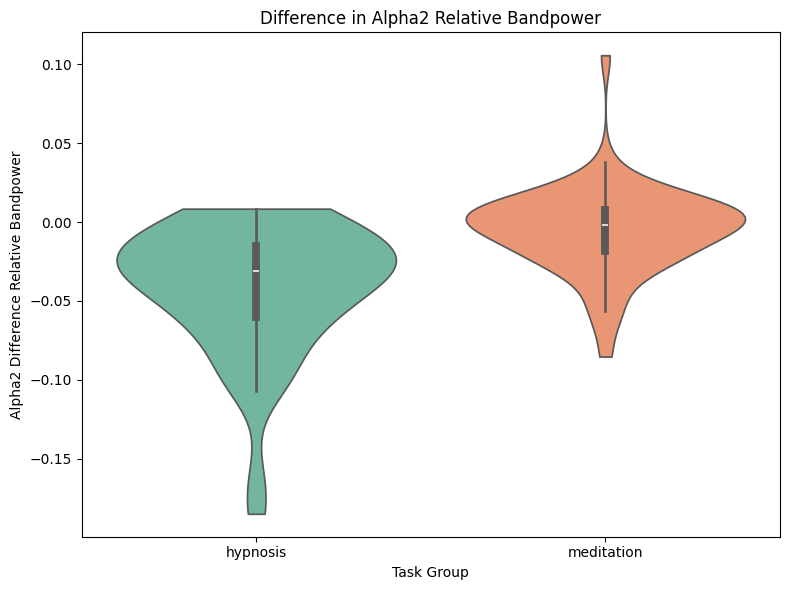

In [10]:
df_plot = pd.DataFrame({
    'value': list(hyp_d) + list(med_d),
    'group': ['hypnosis'] * len(hyp_d) + ['meditation'] * len(med_d)
})

plt.figure(figsize=(8,6))
sns.violinplot(
    data=df_plot,
    x='group',
    y='value',
    inner='box',        # shows median + IQR
    cut=0,              # avoids extending beyond data range
    palette='Set2'
)

plt.title('Difference in Alpha2 Relative Bandpower')
plt.xlabel('Task Group')
plt.ylabel('Alpha2 Difference Relative Bandpower')
plt.tight_layout()
plt.show()

C:\Users\tramy\AppData\Local\Temp\ipykernel_26156\2388543771.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


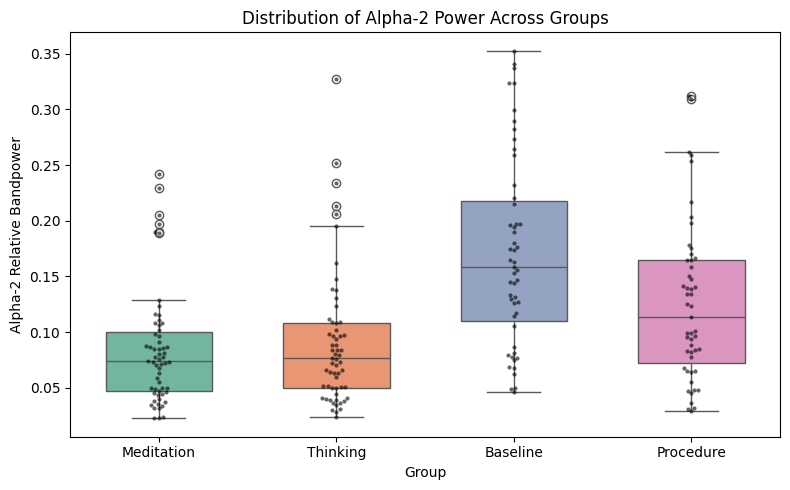

In [22]:
#power spectral density plot in all 4 condition 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = df.rename(columns={
    'meditation_cond': 'Meditation',
    'thinking_cond': 'Thinking',
    'baseline_cond': 'Baseline',
    'procedure_cond': 'Hypnosis'
})
df_long = df.reset_index().melt(
    id_vars='subject',
    var_name='condition',
    value_name='alpha2_power'
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x='condition',
    y='alpha2_power',
    palette='Set2',
    width=0.6
)

sns.swarmplot(
    data=df_long,
    x='condition',
    y='alpha2_power',
    color='black',
    size=3,
    alpha=0.6
)

plt.xlabel("Group")
plt.ylabel("Alpha‑2 Relative Bandpower")
plt.title("Distribution of Alpha‑2 Power Across Groups")
plt.tight_layout()
plt.show()
